In [4]:
import pandas as pd
df = pd.read_csv("../data/raw/netflix_titles.csv")
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [5]:
print(df['listed_in'].head(10))
print(df['listed_in'].nunique())

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
5                   TV Dramas, TV Horror, TV Mysteries
6                             Children & Family Movies
7     Dramas, Independent Movies, International Movies
8                         British TV Shows, Reality TV
9                                     Comedies, Dramas
Name: listed_in, dtype: str
514


In [6]:
# Step 1: split the string into a list
df['genre_list'] = df['listed_in'].str.split(', ')

# Step 2: explode — one row per (title, genre) pair
genre_exploded = df.explode('genre_list')

# Step 3: now this gives TRUE genre distribution
genre_counts = genre_exploded['genre_list'].value_counts()
print(genre_counts)
print(f"\nTrue number of unique genres: {genre_exploded['genre_list'].nunique()}")

genre_list
International Movies            2752
Dramas                          2427
Comedies                        1674
International TV Shows          1351
Documentaries                    869
Action & Adventure               859
TV Dramas                        763
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
TV Comedies                      581
Thrillers                        577
Crime TV Shows                   470
Kids' TV                         451
Docuseries                       395
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 253
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     176
Spanish-Language TV Shows        174
TV Action & Adventure            168
Korean TV Shows            

In [7]:
import pandas as pd

df = pd.read_csv("../data/raw/netflix_titles.csv")

df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

df.to_csv("../data/processed/netflix_titles_clean.csv", index=False)
print("Saved:", df.shape)

Saved: (8807, 12)


In [9]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
from data_generator import build_user_dataset, PERSONAS
from interactions import build_interaction_table

catalog = pd.read_csv("../data/processed/netflix_titles_clean.csv")
catalog["genre_list"] = catalog["listed_in"].str.split(", ")

user_df = pd.read_csv("../data/processed/synthetic_viewing_behavior.csv")

rng = np.random.default_rng(42)
interactions = build_interaction_table(user_df, catalog, PERSONAS, rng)

interactions.to_csv("../data/processed/viewing_interactions.csv", index=False)
print(interactions.shape)
interactions.head()

(539474, 6)


,user_id,persona,show_id,title,genre_list,completion_rate
0,1,weekend_watcher,s6642,Dragonheart,"[Action & Adventure, Sci-Fi & Fantasy]",0.709790
1,1,weekend_watcher,s3716,Mike Epps: Only One Mike,[Stand-Up Comedy],0.851591
2,1,weekend_watcher,s7458,Mini Wolf,[Kids' TV],0.600263
3,1,weekend_watcher,s5912,Jen Kirkman: I'm Gonna Die Alone (And I Feel F...,[Stand-Up Comedy],0.820855
4,1,weekend_watcher,s816,The Girl King,"[Dramas, International Movies, LGBTQ Movies]",0.766897


In [10]:
check = interactions.groupby('user_id').size().reset_index(name='actual_watched')
merged = user_df.merge(check, on='user_id', how='left')
print((merged['total_sessions'] == merged['actual_watched']).mean())  # should be ~1.0 (100% match)

0.9966


In [11]:
merged['actual_watched'] = merged['actual_watched'].fillna(0)
print((merged['total_sessions'] == merged['actual_watched']).mean())  # should now be exactly 1.0

1.0


In [12]:
interactions = pd.read_csv("../data/processed/viewing_interactions.csv")

import ast
interactions['genre_list'] = interactions['genre_list'].apply(ast.literal_eval)

exploded = interactions.explode('genre_list')

genre_completion = (
    exploded.groupby('genre_list')['completion_rate']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)

print(genre_completion)

                                  mean   count
genre_list                                    
Sci-Fi & Fantasy              0.780540   25683
TV Dramas                     0.736210   84583
Crime TV Shows                0.735781   52213
Thrillers                     0.735095   64607
TV Mysteries                  0.733808    8629
Classic & Cult TV             0.732853    1627
Spanish-Language TV Shows     0.729825   13041
International TV Shows        0.729653   98508
TV Thrillers                  0.728148    4309
TV Horror                     0.727808    4894
Anime Features                0.727475    3137
Teen TV Shows                 0.727184    4770
TV Action & Adventure         0.727142   12593
Horror Movies                 0.726400   24238
TV Sci-Fi & Fantasy           0.725556    5750
Docuseries                    0.724784   21396
Romantic TV Shows             0.722358   21639
Korean TV Shows               0.721910    8219
TV Comedies                   0.720407   30829
Science & Nat

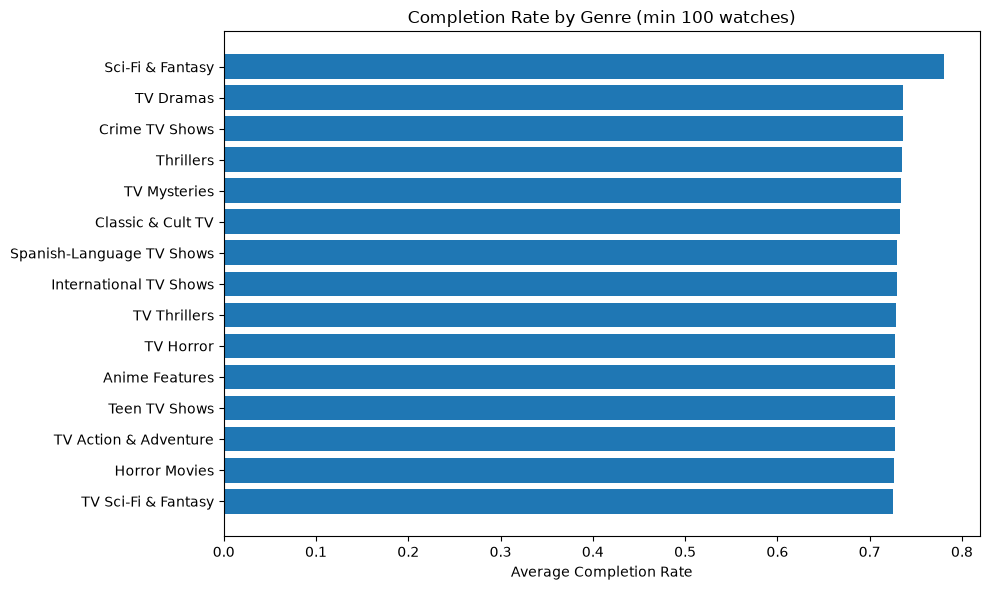

In [13]:
import matplotlib.pyplot as plt

top_genres = genre_completion[genre_completion['count'] >= 100].head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_genres.index, top_genres['mean'])
plt.xlabel('Average Completion Rate')
plt.title('Completion Rate by Genre (min 100 watches)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
# --- Binge vs Casual viewer classification ---

q75 = user_df['avg_sessions_per_week'].quantile(0.75)
q25 = user_df['avg_sessions_per_week'].quantile(0.25)

def classify_viewer(row):
    if row['avg_sessions_per_week'] >= q75:
        return 'Binge Viewer'
    elif row['avg_sessions_per_week'] <= q25:
        return 'Casual Viewer'
    else:
        return 'Moderate Viewer'

user_df['viewer_type'] = user_df.apply(classify_viewer, axis=1)

print(user_df['viewer_type'].value_counts())
print()

print(pd.crosstab(user_df['persona'], user_df['viewer_type']))

viewer_type
Moderate Viewer    2466
Binge Viewer       1271
Casual Viewer      1263
Name: count, dtype: int64

viewer_type      Binge Viewer  Casual Viewer  Moderate Viewer
persona                                                      
casual_viewer             241              0             1279
churning_user               0            717              266
new_user                    0            493                0
power_binger             1025              0                0
weekend_watcher             5             53              921


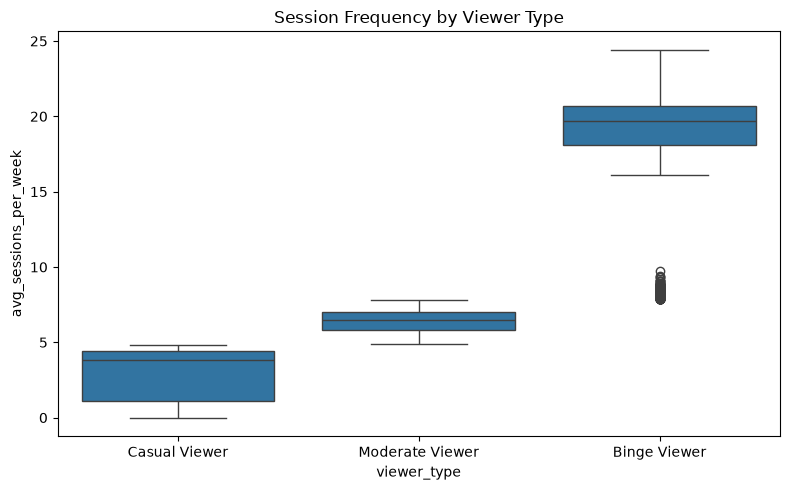

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(data=user_df, x='viewer_type', y='avg_sessions_per_week',
            order=['Casual Viewer', 'Moderate Viewer', 'Binge Viewer'])
plt.title('Session Frequency by Viewer Type')
plt.tight_layout()
plt.show()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


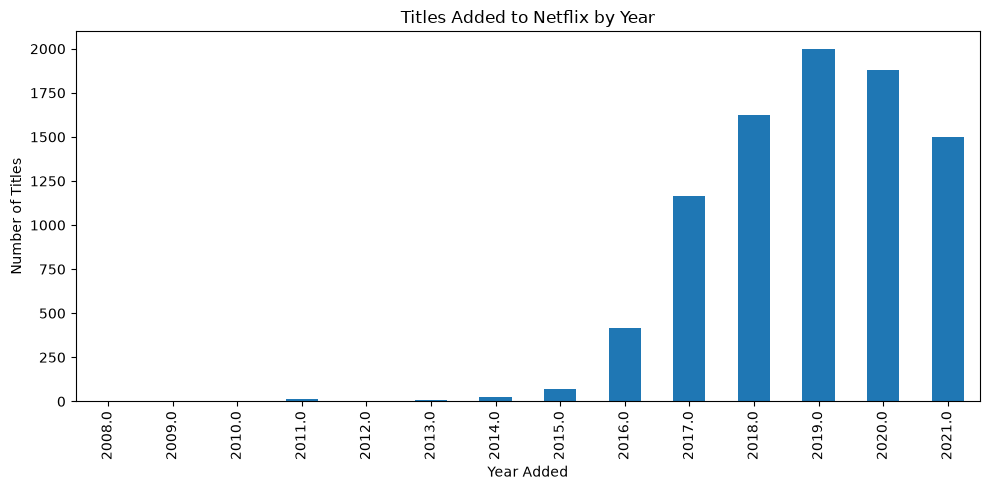

In [16]:
# --- Time-based trends in content addition ---

catalog = pd.read_csv("../data/processed/netflix_titles_clean.csv")

# date_added is currently a string like "September 25, 2021" -- needs parsing
catalog['date_added'] = pd.to_datetime(catalog['date_added'], errors='coerce')
# errors='coerce' turns unparseable strings into NaT instead of crashing --
# useful safety net for messy real-world date columns like this one

catalog['year_added'] = catalog['date_added'].dt.year
catalog['month_added'] = catalog['date_added'].dt.month

# how many titles added per year
titles_per_year = catalog['year_added'].value_counts().sort_index()
print(titles_per_year)

plt.figure(figsize=(10, 5))
titles_per_year.plot(kind='bar')
plt.title('Titles Added to Netflix by Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

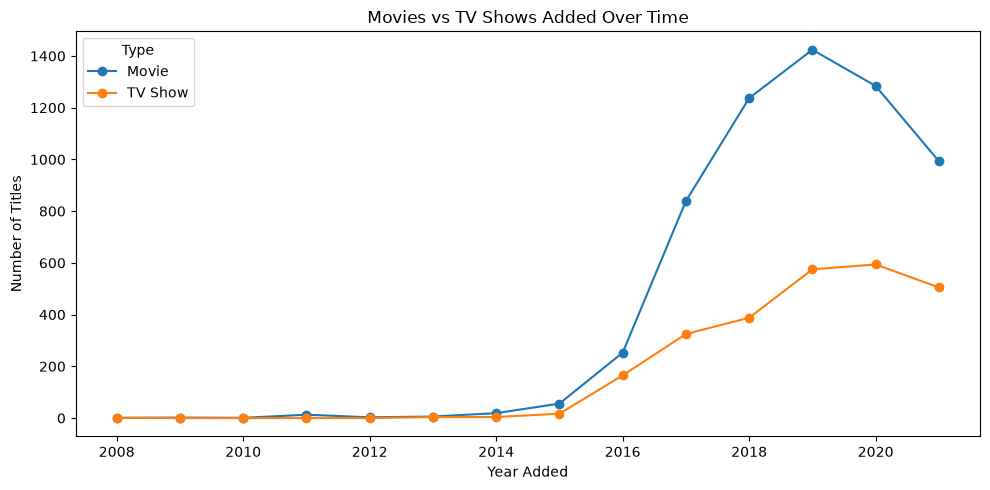

In [17]:
type_trend = catalog.groupby(['year_added', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 5))
type_trend.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Movies vs TV Shows Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.tight_layout()
plt.show()